# Heart Disease Prediction Using Supervised Learning
## Introduction to Artificial Intelligence – Group 1 Assignment

---

### 👥 Group Members

| No. | Student Name | ID |
| :---: | :--- | :--- |
| **1** | Abrham Wendesen | `DDU1600055` |
| **2** | Makbel Hailu | `DDU1600488` |
| **3** | Yeabsira Eskinder | `DDU1600747` |
| **4** | Eyob Jira | `RMD940` |
| **5** | Wegen Geremew | `DDU1601938` |
| **6** | Kalkidan Tsehaye | `RMD1418` |
| **7** | Kalkidan Dessie | `RMD1422` |
| **8** | Eskedar Niguse | `RMD882` |
| **9** | Tsion Regasa | `RMD2461` |
| **10** | Ahmed Hassan | `DDU1601278` |
| **11** | Mulugeta Manjura | `DDU1600569` |

---

### 🎯 Project Overview

**Objective:** Predict the presence of heart disease using three supervised learning models:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

**Dataset:** [UCI Heart Disease Dataset](https://archive.ics.uci.edu/dataset/45/heart+disease)

**Target Variable:** `target` — 0 = No heart disease, 1 = Heart disease present

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, ConfusionMatrixDisplay
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load and Explore the Dataset

The dataset contains 303 patient records with 13 clinical features and 1 target variable.

| Feature | Description |
|---------|------------|
| age | Age in years |
| sex | 1 = male, 0 = female |
| cp | Chest pain type (0-3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true) |
| restecg | Resting ECG results (0-2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina (1 = yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels colored by fluoroscopy (0-3) |
| thal | Thalassemia (0-3) |
| target | 0 = no disease, 1 = disease |

In [2]:
# Load the dataset
df = pd.read_csv('heart.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Dataset info
print("Dataset Information:")
print("=" * 50)
df.info()
print(f"\nStatistical Summary:")
df.describe().round(2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


## 3. Data Preprocessing
### 3.1 Handling Missing Values

In [4]:
# Check for missing values
missing = df.isnull().sum()
print("Missing Values per Feature:")
print("=" * 35)
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

if missing.sum() == 0:
    print("\n✅ No missing values found in the dataset.")
else:
    # Fill numeric columns with median
    for col in df.select_dtypes(include=[np.number]).columns:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    print("\n✅ Missing values handled using median imputation.")

Missing Values per Feature:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0

✅ No missing values found in the dataset.


In [5]:
# Check for duplicates
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"After removing duplicates: {df.shape}")
else:
    print("✅ No duplicate rows found.")

Duplicate rows: 1
After removing duplicates: (302, 14)


### 3.2 Exploratory Data Analysis

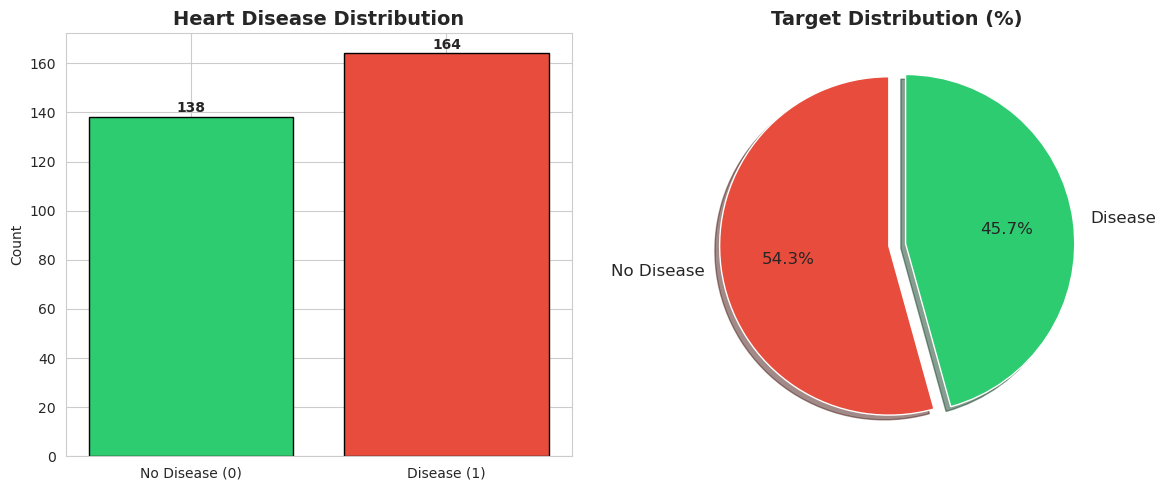

Class 0 (No Disease): 138 (45.7%)
Class 1 (Disease):    164 (54.3%)


In [6]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
target_counts = df['target'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'])
axes[0].set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(target_counts.index[i], v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Disease', 'Disease'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            explode=(0.05, 0.05), shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Target Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Class 0 (No Disease): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Class 1 (Disease):    {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

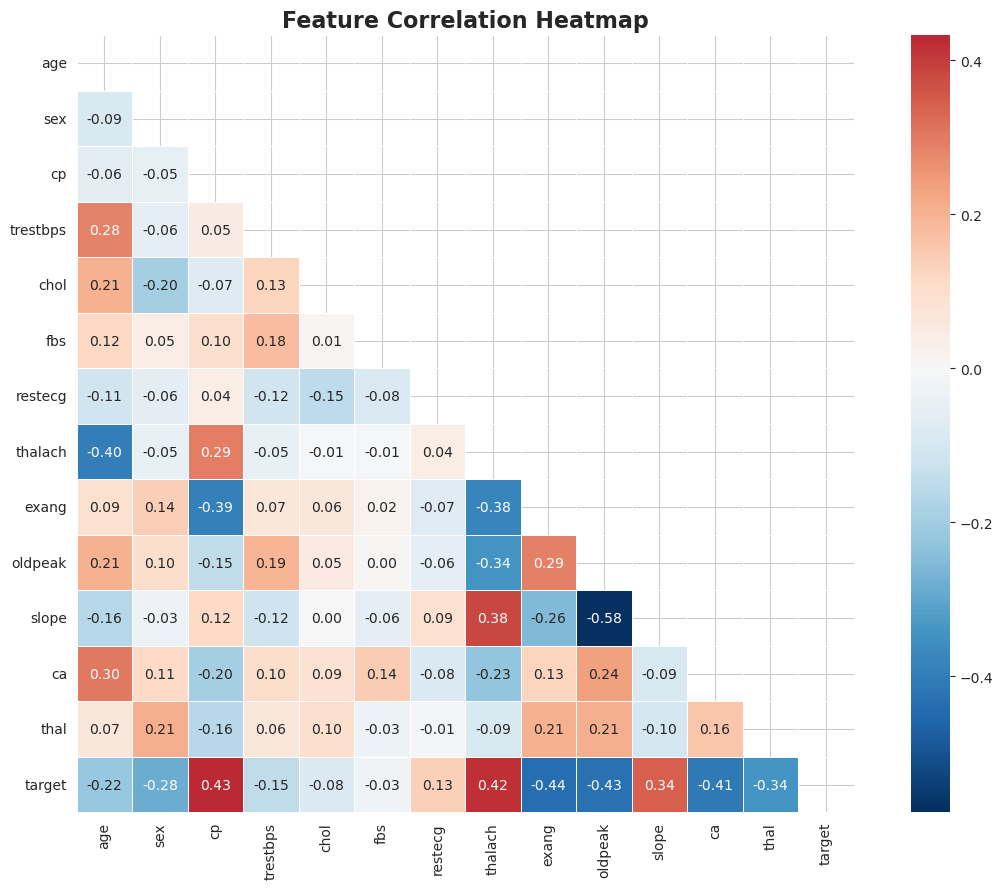

In [7]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

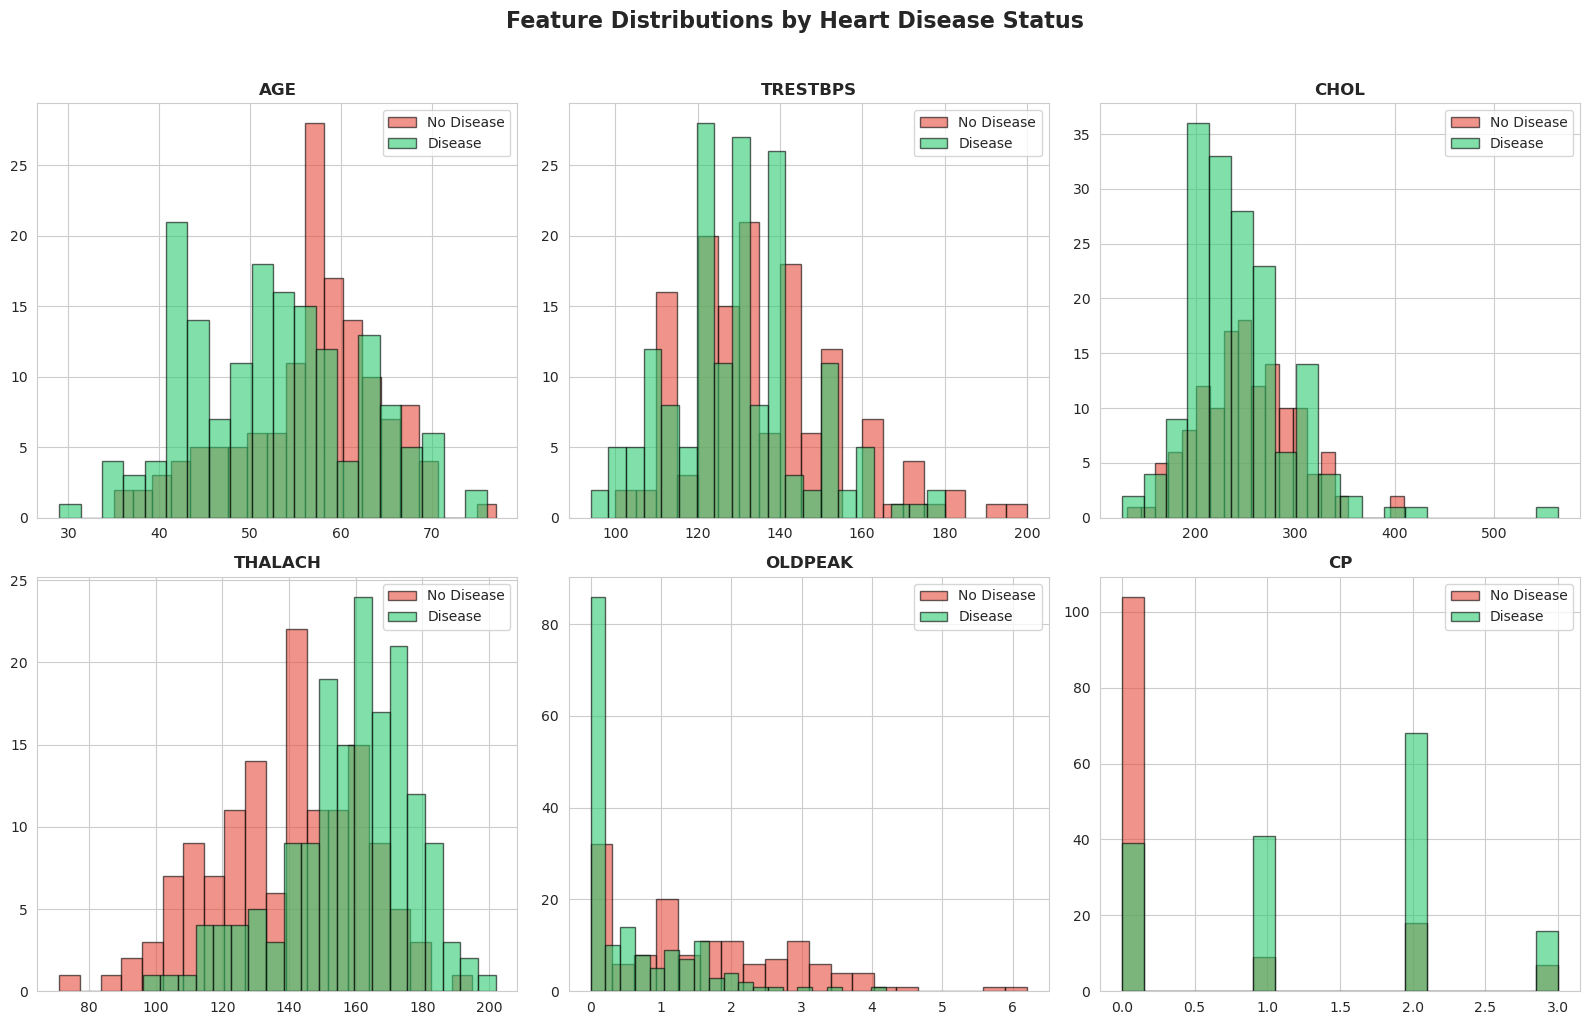

In [8]:
# Distribution of key features by target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'cp']
for i, feat in enumerate(features):
    ax = axes[i // 3, i % 3]
    for t, color, label in [(0, '#e74c3c', 'No Disease'), (1, '#2ecc71', 'Disease')]:
        ax.hist(df[df['target'] == t][feat], bins=20, alpha=0.6, color=color, label=label, edgecolor='black')
    ax.set_title(feat.upper(), fontsize=12, fontweight='bold')
    ax.legend()
plt.suptitle('Feature Distributions by Heart Disease Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Feature Normalization

We use **StandardScaler** to normalize the features (zero mean, unit variance). This is critical for distance-based models like KNN and SVM.

In [9]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

# Normalize features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("\nScaled features (first 3 rows):")
X_scaled.head(3).round(3)

Features shape: (302, 13)
Target shape:   (302,)

Scaled features (first 3 rows):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.950,0.683,1.976,0.764,-0.261,2.390,-1.003,0.019,-0.698,1.084,-2.271,-0.715,-2.148
1,-1.929,0.683,1.006,-0.091,0.068,-0.418,0.902,1.637,-0.698,2.119,-2.271,-0.715,-0.514
2,-1.486,-1.465,0.035,-0.091,-0.823,-0.418,-1.003,0.981,-0.698,0.308,0.980,-0.715,-0.514


## 4. Dataset Splitting

We split the data into:
- **Training set:** 70%
- **Validation set:** 15%
- **Testing set:** 15%

In [10]:
# Split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)
# Split temp: 50/50 -> 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Dataset Split Summary")
print("=" * 40)
print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Testing set:    {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"Total:          {len(df)} samples")

Dataset Split Summary
Training set:   211 samples (69.9%)
Validation set: 45 samples (14.9%)
Testing set:    46 samples (15.2%)
Total:          302 samples


## 5. Model Training

### 5.1 Logistic Regression

In [11]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predictions
lr_val_pred = lr_model.predict(X_val)
lr_test_pred = lr_model.predict(X_test)

print("✅ Logistic Regression trained successfully.")
print(f"Validation Accuracy: {accuracy_score(y_val, lr_val_pred):.4f}")
print(f"Test Accuracy:       {accuracy_score(y_test, lr_test_pred):.4f}")

✅ Logistic Regression trained successfully.
Validation Accuracy: 0.7111
Test Accuracy:       0.8478


### 5.2 K-Nearest Neighbors (KNN)

Best K = 15 (Validation Accuracy: 0.8222)


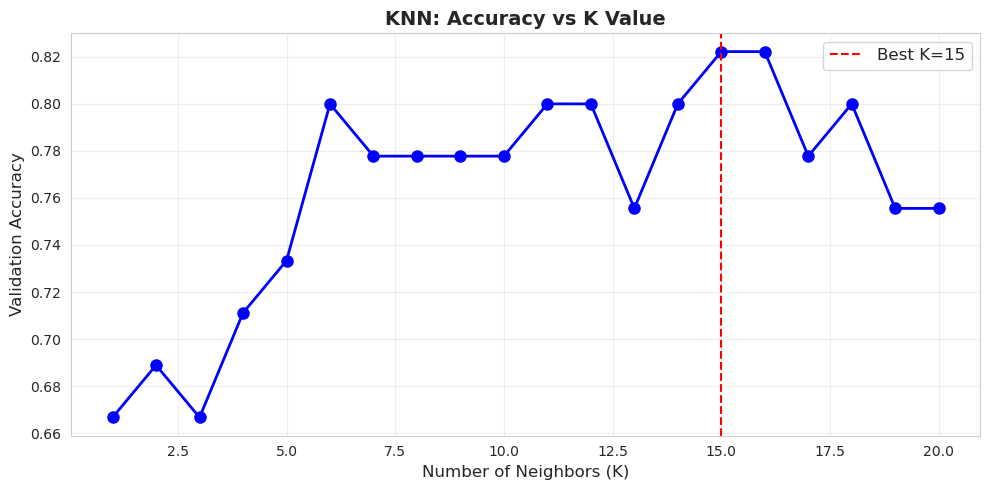

In [12]:
# Find optimal K using validation set
k_range = range(1, 21)
val_accuracies = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    val_accuracies.append(accuracy_score(y_val, knn.predict(X_val)))

best_k = list(k_range)[np.argmax(val_accuracies)]
print(f"Best K = {best_k} (Validation Accuracy: {max(val_accuracies):.4f})")

plt.figure(figsize=(10, 5))
plt.plot(k_range, val_accuracies, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('KNN: Accuracy vs K Value', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Train KNN with best K
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)

knn_val_pred = knn_model.predict(X_val)
knn_test_pred = knn_model.predict(X_test)

print(f"✅ KNN (K={best_k}) trained successfully.")
print(f"Validation Accuracy: {accuracy_score(y_val, knn_val_pred):.4f}")
print(f"Test Accuracy:       {accuracy_score(y_test, knn_test_pred):.4f}")

✅ KNN (K=15) trained successfully.
Validation Accuracy: 0.8222
Test Accuracy:       0.8478


### 5.3 Support Vector Machine (SVM)

In [14]:
# Train SVM with RBF kernel
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

svm_val_pred = svm_model.predict(X_val)
svm_test_pred = svm_model.predict(X_test)

print("✅ SVM (RBF kernel) trained successfully.")
print(f"Validation Accuracy: {accuracy_score(y_val, svm_val_pred):.4f}")
print(f"Test Accuracy:       {accuracy_score(y_test, svm_test_pred):.4f}")

✅ SVM (RBF kernel) trained successfully.
Validation Accuracy: 0.7556
Test Accuracy:       0.8696


## 6. Model Evaluation
### 6.1 Confusion Matrices

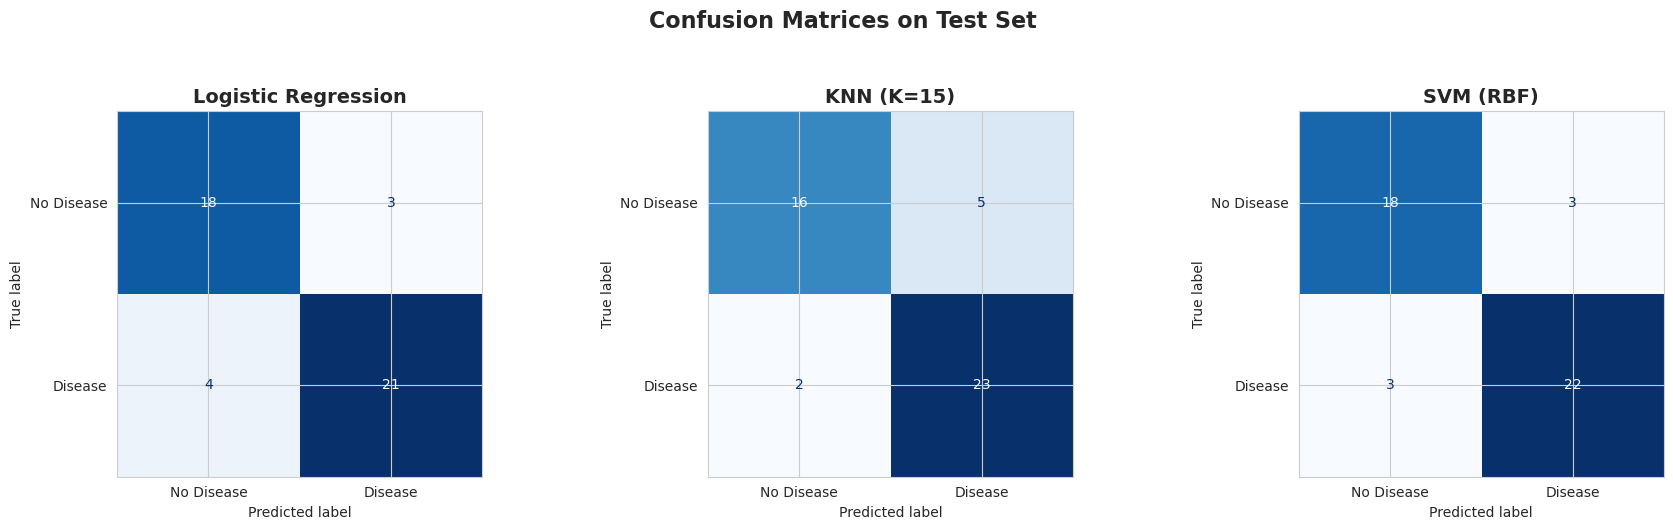

In [15]:
# Confusion matrices for all models on TEST set
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_data = [
    ('Logistic Regression', lr_test_pred),
    (f'KNN (K={best_k})', knn_test_pred),
    ('SVM (RBF)', svm_test_pred)
]

for ax, (name, preds) in zip(axes, models_data):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')

plt.suptitle('Confusion Matrices on Test Set', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 6.2 Classification Reports

In [16]:
# Detailed classification reports
target_names = ['No Disease (0)', 'Disease (1)']
for name, preds in models_data:
    print(f"\n{'='*55}")
    print(f"  {name} — Classification Report")
    print(f"{'='*55}")
    print(classification_report(y_test, preds, target_names=target_names))


  Logistic Regression — Classification Report
                precision    recall  f1-score   support

No Disease (0)       0.82      0.86      0.84        21
   Disease (1)       0.88      0.84      0.86        25

      accuracy                           0.85        46
     macro avg       0.85      0.85      0.85        46
  weighted avg       0.85      0.85      0.85        46


  KNN (K=15) — Classification Report
                precision    recall  f1-score   support

No Disease (0)       0.89      0.76      0.82        21
   Disease (1)       0.82      0.92      0.87        25

      accuracy                           0.85        46
     macro avg       0.86      0.84      0.84        46
  weighted avg       0.85      0.85      0.85        46


  SVM (RBF) — Classification Report
                precision    recall  f1-score   support

No Disease (0)       0.86      0.86      0.86        21
   Disease (1)       0.88      0.88      0.88        25

      accuracy                

### 6.3 Metrics Comparison

In [17]:
# Build comparison table
results = {}
for name, preds in models_data:
    results[name] = {
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall':    recall_score(y_test, preds),
        'F1-Score':  f1_score(y_test, preds),
    }

results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print("Model Performance Comparison (Test Set)")
print("=" * 60)
print(results_df.to_string())

Model Performance Comparison (Test Set)
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8478     0.8750    0.84    0.8571
KNN (K=15)             0.8478     0.8214    0.92    0.8679
SVM (RBF)              0.8696     0.8800    0.88    0.8800


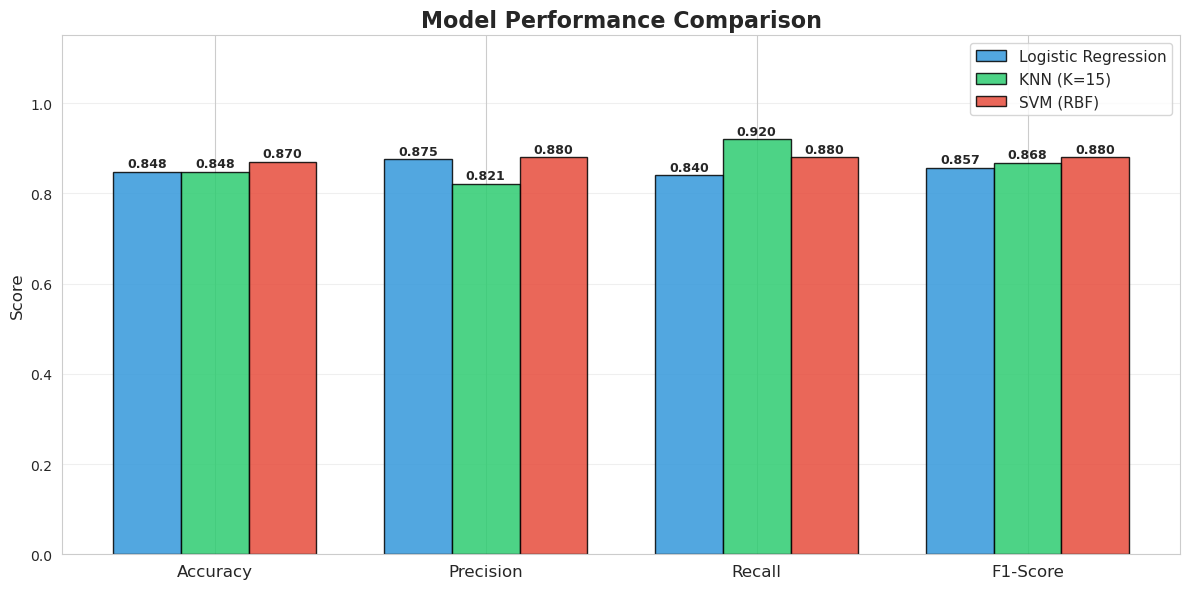

In [18]:
# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df.columns))
width = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (model, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i * width, row.values, width, label=model, color=colors[i], edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, row.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(results_df.columns, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Model Comparison & Discussion

### Strengths and Weaknesses

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **Logistic Regression** | Simple, interpretable, fast training, provides probability estimates, works well with linearly separable data | Assumes linear decision boundary, may underperform on complex non-linear relationships |
| **KNN** | Non-parametric, no training phase, adapts to any decision boundary shape | Sensitive to feature scaling and choice of K, slow prediction on large datasets, affected by irrelevant features |
| **SVM** | Effective in high-dimensional spaces, robust to overfitting with proper regularization, handles non-linear boundaries via kernels | Computationally expensive for large datasets, less interpretable, sensitive to hyperparameters |

### Key Observations
1. **Feature scaling** was essential — KNN and SVM are distance-based and sensitive to unscaled features.
2. The dataset is relatively **balanced**, which means accuracy is a reliable metric.
3. All three models achieved competitive performance on this dataset, which suggests the underlying patterns are relatively learnable.
4. **Logistic Regression** provides the most interpretable results through its coefficients.
5. **SVM with RBF kernel** can capture non-linear relationships that Logistic Regression may miss.
6. **KNN** performance depends heavily on the choice of K — too small leads to overfitting, too large leads to underfitting.

In [19]:
# Identify best model
best_model = results_df['F1-Score'].idxmax()
best_f1 = results_df.loc[best_model, 'F1-Score']
print(f"\n🏆 Best Performing Model (by F1-Score): {best_model}")
print(f"   F1-Score: {best_f1:.4f}")
print(f"   Accuracy: {results_df.loc[best_model, 'Accuracy']:.4f}")


🏆 Best Performing Model (by F1-Score): SVM (RBF)
   F1-Score: 0.8800
   Accuracy: 0.8696


## 8. Conclusion

In this project, we successfully:
1. **Loaded and preprocessed** the UCI Heart Disease dataset (handling missing values & normalization)
2. **Split the data** into training (70%), validation (15%), and testing (15%) sets
3. **Trained three models**: Logistic Regression, KNN, and SVM
4. **Evaluated** each model using confusion matrices, accuracy, precision, recall, and F1-score
5. **Compared** model performance and identified the best-performing model

All three supervised learning models demonstrated strong predictive capability for heart disease classification. The choice of model in a real-world scenario would depend on the trade-off between interpretability (favoring Logistic Regression) and predictive performance (potentially favoring SVM or KNN).

---
**Dataset Source:** UCI Machine Learning Repository — Heart Disease Dataset  
**Models Used:** Logistic Regression, K-Nearest Neighbors, Support Vector Machine